## Matplotlib & Basic Stats

Let's spend a bit more time plotting data and exploring the data. Exploring, poking, and prodding the data is part of the data science process.  We can learn about what we have by using basic descriptive statistics (e.g. min/max values, variance, range, shape).  Our focus today is really on **descriptive statistics**, that is, answering the question "What do I have?". This is different from **inferential statistics** where the focus is "What can I conclude?".

You should be able to recognize two general types of data: **quantitative** and **qualitative**

### Quantitative (numerical)​
Two types are discrete and continuous

**Discrete** consists of integers and whole numbers. They can only be counted not measured (example: number of students in a class). They tend to have finite number of possibilities. These values are commonly viewed in bar charts. 

**Continuous** consists of fractional numbers. These tend to have an infinite number of possibilities. They are commonly viewed in histograms, boxplots, or scatterplots.

### Qualitative (categorical)
Two types are nominal and ordinal

**Nominal** are categorical values (or labels) that don't have a natural ordering (example: marital status, eye color).  They are commonly viewed in pie charts or bar charts. 

**Ordinal** are categorical values that have a natural ordering (example: low medium high, letter grades, months). They are commonly viewed in pie charts or bar charts. 

### Review: What type of data is this?

1. Number of computers in a lab?
2. Temperature?
3. Student majors?
4. Type of device used (e.g. laptop, phone)?
5. Letter grade (A, B, ...)?
6. State of residence?
7. Number of emails received today?

In [2]:
# good practice to group imports together at the top
# we need numpy, pandas, and pyplot from matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Let's import some flight delay data
# Original source of data is https://www.transtats.bts.gov/OT_Delay/OT_DelayCause1.asp
df2019 = pd.read_csv('delays_2019.csv')

In [6]:
# use len() to get number of rows
len(df2019)

20946

In [12]:
# view first 5 rows
df2019.head()

,date,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2019-1,MQ,Envoy Air,SAV,"Savannah, GA: Savannah/Hilton Head International",65.0,15.0,3.41,0.71,4.33,0.0,6.56,1.0,1.0,601.0,180.0,29.0,129.0,0.0,263.0
1,2019-1,MQ,Envoy Air,SDF,"Louisville, KY: Louisville Muhammad Ali Intern...",61.0,18.0,2.70,1.01,8.93,0.0,5.37,1.0,0.0,890.0,180.0,36.0,383.0,0.0,291.0
2,2019-1,MQ,Envoy Air,SGF,"Springfield, MO: Springfield-Branson National",428.0,80.0,13.31,5.18,27.42,0.0,34.09,15.0,0.0,3954.0,705.0,213.0,982.0,0.0,2054.0
3,2019-1,MQ,Envoy Air,SHV,"Shreveport, LA: Shreveport Regional",174.0,28.0,5.97,1.17,11.15,0.0,9.72,0.0,0.0,1655.0,360.0,55.0,268.0,0.0,972.0
4,2019-1,MQ,Envoy Air,SJT,"San Angelo, TX: San Angelo Regional/Mathis Field",135.0,23.0,10.78,0.35,6.54,0.0,5.33,2.0,0.0,835.0,320.0,27.0,192.0,0.0,296.0


In [14]:
# learn a bit about the data (info)
df2019.info()
# What type of data do we have? Quantitative (discrete vs. continuous)? Qualitative (nominal vs. ordinal)? 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20946 entries, 0 to 20945
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 20946 non-null  object 
 1   carrier              20946 non-null  object 
 2   carrier_name         20946 non-null  object 
 3   airport              20946 non-null  object 
 4   airport_name         20946 non-null  object 
 5   arr_flights          20932 non-null  float64
 6   arr_del15            20927 non-null  float64
 7   carrier_ct           20932 non-null  float64
 8   weather_ct           20932 non-null  float64
 9   nas_ct               20932 non-null  float64
 10  security_ct          20932 non-null  float64
 11  late_aircraft_ct     20932 non-null  float64
 12  arr_cancelled        20932 non-null  float64
 13  arr_diverted         20932 non-null  float64
 14  arr_delay            20932 non-null  float64
 15  carrier_delay        20932 non-null 

In [16]:
# let's drop missing values (dropna)
# note that we are doing minimal clean up - does even begin to address other issues like outliers and duplicates
df2019 = df2019.dropna()
#df2019.dropna(inplace=True)

In [18]:
df2019.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20927 entries, 0 to 20945
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 20927 non-null  object 
 1   carrier              20927 non-null  object 
 2   carrier_name         20927 non-null  object 
 3   airport              20927 non-null  object 
 4   airport_name         20927 non-null  object 
 5   arr_flights          20927 non-null  float64
 6   arr_del15            20927 non-null  float64
 7   carrier_ct           20927 non-null  float64
 8   weather_ct           20927 non-null  float64
 9   nas_ct               20927 non-null  float64
 10  security_ct          20927 non-null  float64
 11  late_aircraft_ct     20927 non-null  float64
 12  arr_cancelled        20927 non-null  float64
 13  arr_diverted         20927 non-null  float64
 14  arr_delay            20927 non-null  float64
 15  carrier_delay        20927 non-null  floa

## Plot review
For carrier MQ arriving at airport SAV, we want to determine the number of flights arriving and compare over the 12 month 2019 period. We then want to plot this using the [plot()](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html#matplotlib.axes.Axes.plot) function. See [https://matplotlib.org/](https://matplotlib.org/).   

Note: The xticks(rotation=degrees) function will allow use to rotate our axis labels if they are difficult to read (overlapping). 

In [30]:
# first create a DataFrame with carrier MQ and destination airport SAV
mq_flights_df = df2019[df2019["carrier"] == 'MQ']
mq_flights_df
mq_sav_flights_df = df2019[(df2019["carrier"] == 'MQ') & (df2019["airport"] == 'SAV')]
df = mq_sav_flights_df

Text(0, 0.5, 'Number of Flights')

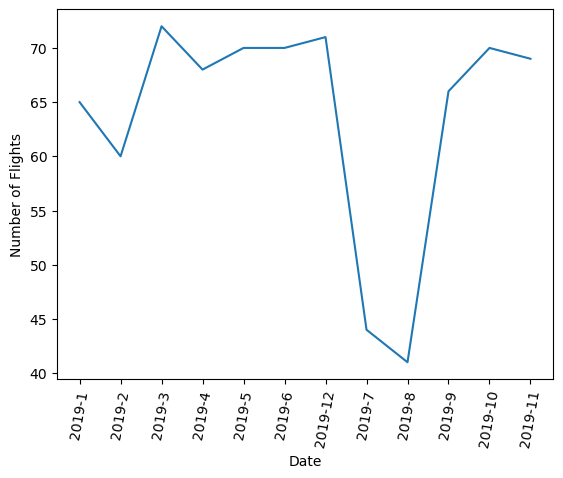

In [46]:
# plot the data (date on x-axis, arr_flights on the y-axis)
# note: show 2 ways. You can provide just the label names and then use the data argument of the plot() function.
#plt.plot(df["date"], df["arr_flights"])
#plt.xticks(rotation=80)

plt.plot("date", "arr_flights", data=df)
plt.xticks(rotation=80)
plt.xlabel("Date")
plt.ylabel("Number of Flights")

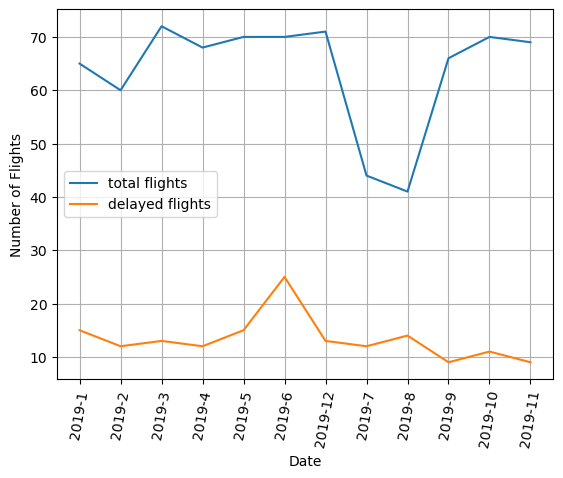

In [57]:
# Let's add a bit more data to the plot
# Let's also plot the number of flights delayed on same plot (arr_del15)
# Use the label argument for each plot() and then call the legend() function to generate a nice legend for readability
plt.plot("date", "arr_flights", data=df, label="total flights")
plt.plot("date", "arr_del15", data=df, label="delayed flights")
plt.xticks(rotation=80)
plt.xlabel("Date")
plt.ylabel("Number of Flights")
plt.legend()
plt.grid()

## Styling plots

Part of the fun with plots is that we can style them.  We can change colors, line style, fonts, and more.  We can pass the styles as a fmt (format) argument in the plot() function.  

See https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html and scroll to "Format Strings" section. 

Format strings consist of the following: fmt = '[marker][line][color]'

Example:

o:r

o = circle marker

: = dotted line

r = red

Note that format is a positional argument (cannot be passed by keyword and should appear after x and y parameters). If you want to write each separately, you can do it with attributes. See apis: [https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)

Example: <code>plt.scatter(x, y, color="green", marker="*", linestyle="dashed")</code>


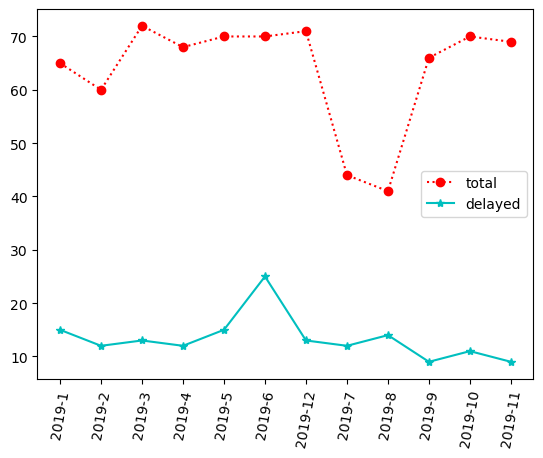

In [59]:
plt.plot(df["date"], df["arr_flights"], "o:r", label="total")
plt.plot(df["date"], df["arr_del15"], "c-*", label="delayed")
plt.xticks(rotation=80)
plt.legend()

You can also display grid lines and manipulate their properties. To add gridlines, we can just call the grid() function of plt.

Properties include:
    * color
    * linestyle
    * linewidth
    
We can also specify which axis to draw with the axis parameter.  By default, both are shown.

_grid(color, linestyle, linewidth, axis)_


In [ ]:
plt.plot(df_mq_sav_tot["date"], df_mq_sav_tot["arr_flights"], "o:r", label="total")
plt.plot(df_mq_sav_tot["date"], df_mq_sav_tot["arr_del15"], "c-*", label="delayed")
plt.xticks(rotation=80)
plt.grid()
plt.legend()

In [ ]:
plt.plot(df_mq_sav_tot["date"], df_mq_sav_tot["arr_flights"], "o:r", label="total")
plt.plot(df_mq_sav_tot["date"], df_mq_sav_tot["arr_del15"], "c-*", label="delayed")
plt.xticks(rotation=80)
plt.grid(color="gray", linestyle=":", linewidth='0.5', axis="y")
plt.legend()

**Question 1**

Create a figure that plots the total number of delays due to weather issues. Do this only for MQ flights. 
Use the scatter() function instead.  Change the marker shape to a diamond, and the color to green. Note that there is no fmt attribute. Need to use color and marker arguments. 

See [https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, '2019-1'),
  Text(1, 0, '2019-2'),
  Text(2, 0, '2019-3'),
  Text(3, 0, '2019-4'),
  Text(4, 0, '2019-5'),
  Text(5, 0, '2019-6'),
  Text(6, 0, '2019-12'),
  Text(7, 0, '2019-7'),
  Text(8, 0, '2019-8'),
  Text(9, 0, '2019-9'),
  Text(10, 0, '2019-10'),
  Text(11, 0, '2019-11')])

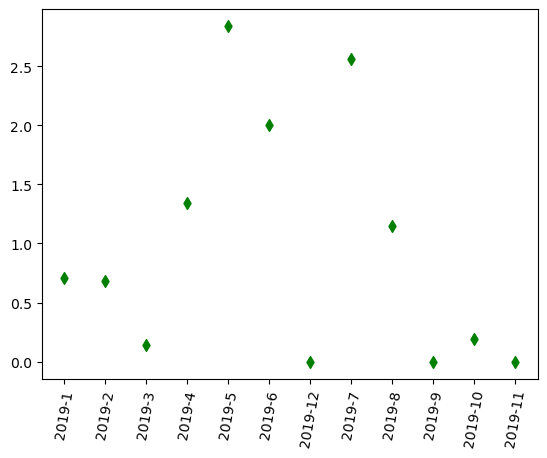

In [75]:
# We want to plot the carrier and total number of delays due to weather issue (weather_ct) over time

plt.scatter("date", "weather_ct", data=df, color="green", marker="d")
plt.xticks(rotation=80)

In [ ]:
# note that we can group rows by a common value using the groupby() function, as shown below with aggregation
mq_flights_sum = mq_flights.groupby("date")["weather_ct"].sum()
mq_flights_sum

In [ ]:
# Now replot the data

### Multiple plots

The subplot() function can be used to draw multiple plots on the same figure. This is great for situations where you want to compare plots.  The subplot() function takes 3 parameters: nrows, ncols, and index. subtitle() can add a title to the subplot.


Text(0.5, 0.98, 'Flight Data')

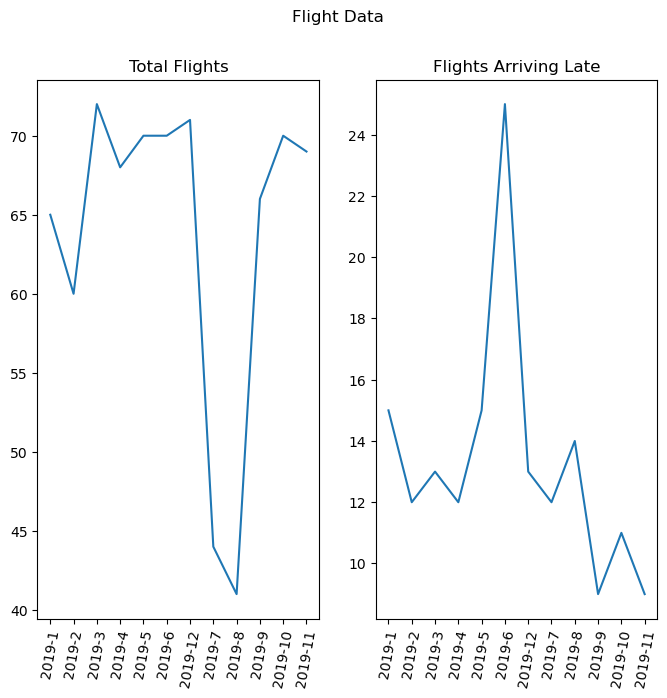

In [81]:
plt.figure(figsize=(8,7))
plt.subplot(1,2,1)
plt.plot(df["date"], df["arr_flights"])
plt.title("Total Flights")
plt.xticks(rotation=80)

plt.subplot(1,2,2)
plt.plot(df["date"], df["arr_del15"])
plt.title("Flights Arriving Late")
plt.xticks(rotation=80)

plt.suptitle("Flight Data")


## Basic Stats

We can't explore and analyze our data without basic statistical techniques. We commonly use sampling and descriptive statistics techniques.

We can use the sample() function from the pandas library to obtain a random sample from an original dataset. 

<code>DataFrame.sample(n=None, frac=None, replace=False, random_state=None) </code>

See [https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html) for more. 

In [85]:
df2019.sample(n=100, replace=False) #100 results
df2019.sample(n=100, replace=False, random_state=3) #100 results & returns the same rows each time we run this

,date,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
6425,2019-5,OH,PSA Airlines Inc.,OMA,"Omaha, NE: Eppley Airfield",62.0,8.0,1.67,0.22,3.49,0.0,2.61,0.0,0.0,292.0,46.0,12.0,66.0,0.0,168.0
20621,2019-1,F9,Frontier Airlines Inc.,DEN,"Denver, CO: Denver International",1676.0,363.0,98.69,12.22,98.03,0.0,154.06,16.0,1.0,24436.0,8656.0,1027.0,4251.0,0.0,10502.0
15605,2019-9,MQ,Envoy Air,GCK,"Garden City, KS: Garden City Regional",60.0,5.0,2.01,0.00,2.99,0.0,0.00,0.0,0.0,118.0,55.0,0.0,63.0,0.0,0.0
14689,2019-8,YX,Republic Airline,HHH,"Hilton Head, SC: Hilton Head Airport",229.0,46.0,13.48,2.00,12.23,0.0,18.29,1.0,1.0,2258.0,577.0,218.0,468.0,0.0,995.0
5236,2019-4,OH,PSA Airlines Inc.,JAX,"Jacksonville, FL: Jacksonville International",61.0,20.0,4.55,2.56,4.56,0.0,8.32,1.0,0.0,1669.0,520.0,246.0,166.0,0.0,737.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18685,2019-11,DL,Delta Air Lines Inc.,PNS,"Pensacola, FL: Pensacola International",222.0,8.0,2.00,0.00,0.91,0.0,5.09,0.0,0.0,289.0,108.0,0.0,20.0,0.0,161.0
4322,2019-4,AA,American Airlines Inc.,DTW,"Detroit, MI: Detroit Metro Wayne County",426.0,100.0,43.12,3.71,17.06,0.0,36.11,11.0,0.0,6267.0,2326.0,967.0,688.0,0.0,2286.0
20411,2019-1,DL,Delta Air Lines Inc.,GNV,"Gainesville, FL: Gainesville Regional",27.0,8.0,3.96,0.00,3.38,0.0,0.66,0.0,0.0,194.0,108.0,0.0,66.0,0.0,20.0
15776,2019-9,OH,PSA Airlines Inc.,FAY,"Fayetteville, NC: Fayetteville Regional/Granni...",133.0,25.0,8.38,1.00,8.05,0.0,7.57,7.0,2.0,1074.0,291.0,62.0,204.0,0.0,517.0


In [ ]:
df2019.sample(frac=0.01, replace=False) #fraction of results (1%)

### Descriptive Statistics

Our DataFrames consist of **features** (or columns). A feature, or variable, is a characteristic that can be measured or observed on an observational unit. Descriptive stats allow us to summarize and describe these features. 

We commonly look at the distribution (possible values the feature can take on). Graphing distributions gives us a better understanding of the dataset. 

We often use histograms and basic stats to explore distributions. 

<code>plt.hist(data, bins)</code>

Let's check out some basic descriptive information and histograms for the number of minutes MQ flights are delayed. We'll work a sample too.

In [102]:
# let's get 100 flights
mq_flights_sample = df2019.sample(n=100, replace=False, random_state=1) 

# get basic descriptive statistics with describe() function
mq_flights_sample.arr_delay.describe()
# same as
# mq_flights_sample["arr_delay"].describe()

count      100.000000
mean      3055.430000
std       8104.668882
min          0.000000
25%        329.000000
50%       1129.000000
75%       2279.750000
max      56079.000000
Name: arr_delay, dtype: float64

Text(0.5, 0, 'Minutes delayed')

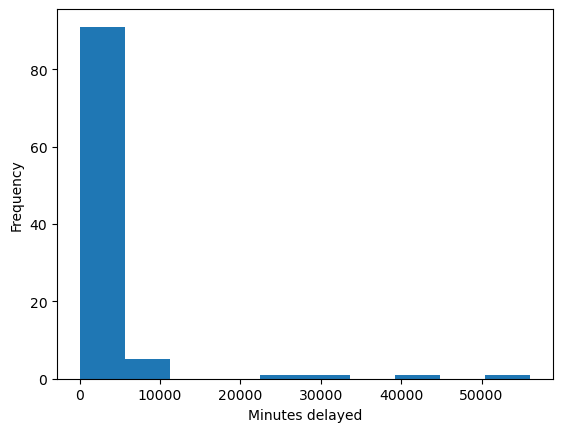

In [93]:
# let's plot as a histogram
plt.hist(mq_flights_sample["arr_delay"])
plt.ylabel("Frequency")
plt.xlabel("Minutes delayed")

Text(0.5, 0, 'Minutes delayed')

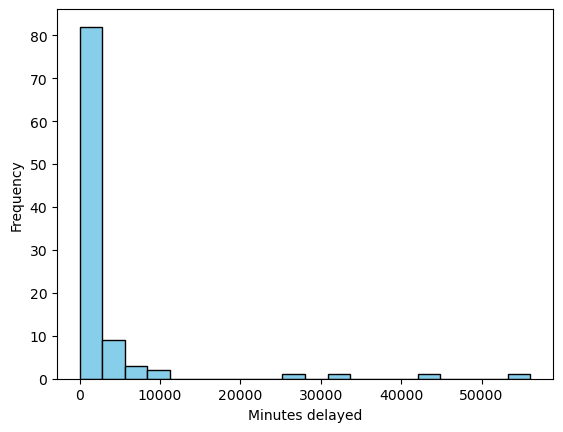

In [95]:
plt.hist(mq_flights_sample["arr_delay"], bins=20, color="skyblue", edgecolor="black")
plt.ylabel("Frequency")
plt.xlabel("Minutes delayed")

Text(0.5, 0, 'Minutes delayed')

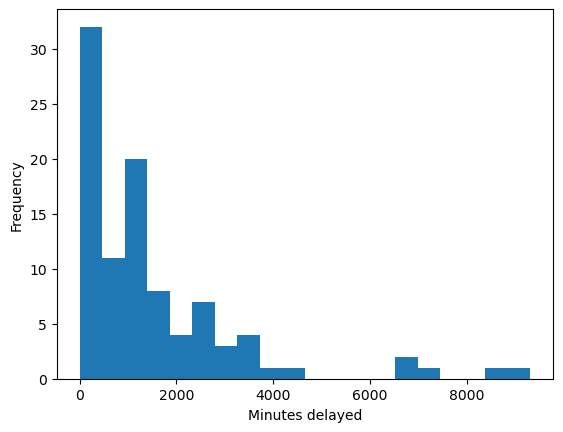

In [97]:
plt.hist(mq_flights_sample[mq_flights_sample["arr_delay"]<10000]["arr_delay"], bins=20)
plt.ylabel("Frequency")
plt.xlabel("Minutes delayed")

Other descriptive values we might want to look at include the variance and standard deviation. They help us better understand the spread of the data. 

Remember, that we already have the range from using that describe() function.  We can also use the min() and max() functions to get those values. 

In [ ]:
# the average squared distance a numerical feature's values lie from the distribution's mean
mq_flights_sample["arr_delay"].var()

In [ ]:
# the square root of the variance and describes how far a numerical feature's values lie, on average, from the distribution's mean.
mq_flights_sample["arr_delay"].std()

We can also determine measures of position with quantiles.  A **quantile** is a value for which a specified proportion of the distribution falls at or below the value.  For example, the median is at the 0.5 quantile mark. **Quartile** is a type of quantile that divides the data set into 4 parts. We often work with quartiles. The typical quartiles are provided with our describe() function.

In [ ]:
mq_flights_sample["arr_delay"].describe()

Interquartile range (IRQ) is the middle 50% of the feature.  

In [ ]:
# Determine the IRQ
mq_flights_sample["arr_delay"].quantile(0.75) - mq_flights_sample["arr_delay"].quantile(0.25) 

In [ ]:
# other quartiles
mq_flights_sample["arr_delay"].quantile(0.5) 
mq_flights_sample["arr_delay"].quantile([0.25, 0.5]) 

Let's look at this visually with boxplots. Boxplots use boxes and lines to show the distributions of groups of numeric data. Boxplots are often based around quartiles. The main box is IQR. The lines or whiskers extend to 1.5 times the IQR. Anything past this is an outlier.

See [https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html)

In [ ]:
# plt.boxplot(mq_flights_sample["arr_delay"])
plt.boxplot(mq_flights_sample["arr_delay"], 0, "") # remove outliers

We also use standardized scores (**z-scores**) to describe how many standard deviations—and in which direction—a value lies from the distribution's mean. We can calculate this using functions.  This will return an array of z-scores that indicates the number of standard deviations a value is from the mean. 

The Three Sigma rule dictates that given a normal distribution, 68% of your observations will fall between one standard deviation of the mean, 95% will fall within two, and 99.7% will fall within three. 

In [ ]:
mean = mq_flights_sample["arr_delay"].mean()
std =  mq_flights_sample["arr_delay"].std()
z_score = (mq_flights_sample["arr_delay"] - mean)/std
z_score

We also look at the shape of a distribution to tell us about the data.  A departure from symmetry is referred to as the skewness.  For example, an extended right tale indicate a skew in the positive direction. A skew less than the absolute value of 0.5 indicates somewhat symmetric data. Values beyond -2 and +2 suggest substantial nonnormality (Hair et al., 2022, p. 66).

Kurtosis measures how heavy a tail is.  A larger kurtosis indicates greater presence of extreme values in the distribution. A kurtosis greater than +2 suggests a too peaked distribution, while less than -2 indicates a too flat one. When skewness and kurtosis are close to zero, it's considered a normal distribution (Hair et al., 2022, p. 66).

In [ ]:
mq_flights_sample["arr_delay"].skew() # what does this tell us?

In [ ]:
mq_flights_sample["arr_delay"].kurtosis() # what does this tell us?

**Question**

Consider the cancelled flights (arr_cancelled) feature.

In [ ]:
# 1. Get a sample of 1000 flights from the original dataset (df2019).


In [ ]:
# 2. Get basic descriptive statistics for the arr_cancelled feature


In [ ]:
# 3. Determine if data is skewed and if so, in what direction.


In [ ]:
# 4. Determine how heavy the tail is


In [ ]:
# 5. Generate a histogram for this feature
# Determine a good bin value based on max and min statistics provided earlier


In [ ]:
# 6. Create two boxplots for this features
# Put both on the same figure
# Draw one with outliers and one without outliers (side-by-side)
# Add an overall title "Cancelled Flights"
